# Week 2 Jupyter Notebook — Linear Regression 2


## Objective

This notebook applies Week 2 regularized regression methods to the flight delay dataset. I used Ridge, Lasso, and Elastic Net regression to see whether regularization improved the linear regression model or made it more stable.

The main reason these methods are useful for this dataset is that several aviation predictors are related to each other, such as airline volume, airport volume, passenger volume, and historical delay variables. Regularization can help shrink unstable coefficients and reduce overfitting.


In [13]:
# Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import warnings
warnings.filterwarnings("ignore")


## 1. Load the datasets

This project uses two dataset sources:

1. **Kaggle 2019 flight delay train/test files** for machine learning modeling.
2. **BTS Flight_Delay file** for supporting delay-cause context from January 2019 through December 2019.

The full Kaggle dataset is very large, so this notebook uses a sample from `train.csv` and `test.csv`. This keeps the notebook easier to run while still giving enough rows to compare the models.

In [14]:
# Load data
# Data files are stored in the data folder.

SAMPLE_SIZE = 100000
TEST_SAMPLE_SIZE = 50000
RANDOM_STATE = 42

train = pd.read_csv("data/train.csv", nrows=SAMPLE_SIZE)
test = pd.read_csv("data/test.csv", nrows=TEST_SAMPLE_SIZE)
flight_delay = pd.read_csv("data/Flight_delay.csv")

print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Flight_Delay shape:", flight_delay.shape)

train.head()


Train shape: (100000, 30)
Test shape: (50000, 30)
Flight_Delay shape: (484551, 29)


,MONTH,DAY_OF_WEEK,DEP_DEL15,DEP_TIME_BLK,DISTANCE_GROUP,SEGMENT_NUMBER,CONCURRENT_FLIGHTS,NUMBER_OF_SEATS,CARRIER_NAME,AIRPORT_FLIGHTS_MONTH,...,PREVIOUS_AIRPORT,PRCP,SNOW,SNWD,TMAX,AWND,CARRIER_HISTORICAL,DEP_AIRPORT_HIST,DAY_HISTORICAL,DEP_BLOCK_HIST
0,7,7,0,1500-1559,3,3,26,160,American Airlines Inc.,19534,...,Chicago O'Hare International,0.00,0.0,0.0,95.0,4.25,0.237709,0.273236,0.222538,0.255479
1,4,1,0,1300-1359,4,4,63,50,SkyWest Airlines Inc.,18788,...,El Paso International,0.00,0.0,0.0,71.0,11.41,0.154651,0.121849,0.237972,0.197503
2,11,4,0,0001-0559,2,1,3,76,American Eagle Airlines Inc.,1148,...,NONE,0.00,0.0,0.0,54.0,0.45,0.117559,0.187867,0.139886,0.060327
3,3,2,0,1500-1559,7,5,14,143,Southwest Airlines Co.,7612,...,San Jose International,0.00,0.0,0.0,64.0,8.05,0.204389,0.141446,0.132868,0.202037
4,7,3,0,0800-0859,1,2,85,50,American Eagle Airlines Inc.,29376,...,Cincinnati/Northern Kentucky International,0.01,0.0,0.0,94.0,10.51,0.203263,0.193761,0.203027,0.113050


## 2. Basic EDA checks

Before modeling, I am checking the target variable and missing values. The target is `DEP_DEL15`, which shows whether a flight had a departure delay of at least 15 minutes.

This target is binary, so logistic regression will be more appropriate later in Week 4. For Week 2, I am using it as a numeric outcome only to apply and compare linear regression, Ridge, Lasso, and Elastic Net.

In [15]:
target = "DEP_DEL15"

print("Target counts:")
print(train[target].value_counts(dropna=False))

print("\nTarget percentage:")
print((train[target].value_counts(normalize=True, dropna=False) * 100).round(2))

print("\nMissing values, top 10:")
print(train.isna().sum().sort_values(ascending=False).head(10))


Target counts:
DEP_DEL15
0    81025
1    18975
Name: count, dtype: int64

Target percentage:
DEP_DEL15
0    81.03
1    18.98
Name: proportion, dtype: float64

Missing values, top 10:
MONTH                 0
DAY_OF_WEEK           0
DAY_HISTORICAL        0
DEP_AIRPORT_HIST      0
CARRIER_HISTORICAL    0
AWND                  0
TMAX                  0
SNWD                  0
SNOW                  0
PRCP                  0
dtype: int64


BTS total delay minutes by cause:
LateAircraftDelay    12915022
CarrierDelay          8440607
NASDelay              6589613
WeatherDelay          1527927
SecurityDelay           39749
dtype: int64


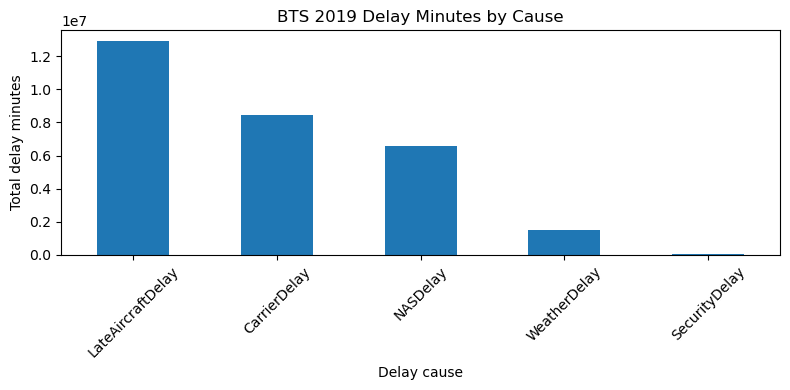

In [16]:
# Simple BTS delay-cause summary for context

bts_delay_cols = [
    "CarrierDelay",
    "WeatherDelay",
    "NASDelay",
    "SecurityDelay",
    "LateAircraftDelay"
]

delay_totals = flight_delay[bts_delay_cols].sum().sort_values(ascending=False)

print("BTS total delay minutes by cause:")
print(delay_totals)

delay_totals.plot(kind="bar", figsize=(8, 4))
plt.title("BTS 2019 Delay Minutes by Cause")
plt.ylabel("Total delay minutes")
plt.xlabel("Delay cause")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 3. Select modeling features

I am using numeric features from the Kaggle dataset because Week 2 focuses on regularized linear regression. Categorical variables can be useful, but adding many dummy variables can make the notebook slower and harder to interpret. For this week, the goal is to focus on how Ridge, Lasso, and Elastic Net handle numeric predictors.

Many of these variables connect directly to the project question:

- weather: `PRCP`, `SNOW`, `SNWD`, `TMAX`, `AWND`
- airport/airline volume: `AIRPORT_FLIGHTS_MONTH`, `AIRLINE_FLIGHTS_MONTH`, `AVG_MONTHLY_PASS_AIRPORT`
- aircraft/route features: `PLANE_AGE`, `DISTANCE_GROUP`, `NUMBER_OF_SEATS`
- historical delay risk: `CARRIER_HISTORICAL`, `DEP_AIRPORT_HIST`, `DAY_HISTORICAL`, `DEP_BLOCK_HIST`

In [17]:
candidate_features = [
    "MONTH",
    "DAY_OF_WEEK",
    "DISTANCE_GROUP",
    "SEGMENT_NUMBER",
    "CONCURRENT_FLIGHTS",
    "NUMBER_OF_SEATS",
    "AIRPORT_FLIGHTS_MONTH",
    "AIRLINE_FLIGHTS_MONTH",
    "AIRLINE_AIRPORT_FLIGHTS_MONTH",
    "AVG_MONTHLY_PASS_AIRPORT",
    "AVG_MONTHLY_PASS_AIRLINE",
    "FLT_ATTENDANTS_PER_PASS",
    "GROUND_SERV_PER_PASS",
    "PLANE_AGE",
    "LATITUDE",
    "LONGITUDE",
    "PRCP",
    "SNOW",
    "SNWD",
    "TMAX",
    "AWND",
    "CARRIER_HISTORICAL",
    "DEP_AIRPORT_HIST",
    "DAY_HISTORICAL",
    "DEP_BLOCK_HIST"
]

features = [col for col in candidate_features if col in train.columns]

model_data = train[features + [target]].dropna()

X = model_data[features]
y = model_data[target]

print("Number of rows used:", X.shape[0])
print("Number of features used:", X.shape[1])
print("Features used:")
print(features)


Number of rows used: 100000
Number of features used: 25
Features used:
['MONTH', 'DAY_OF_WEEK', 'DISTANCE_GROUP', 'SEGMENT_NUMBER', 'CONCURRENT_FLIGHTS', 'NUMBER_OF_SEATS', 'AIRPORT_FLIGHTS_MONTH', 'AIRLINE_FLIGHTS_MONTH', 'AIRLINE_AIRPORT_FLIGHTS_MONTH', 'AVG_MONTHLY_PASS_AIRPORT', 'AVG_MONTHLY_PASS_AIRLINE', 'FLT_ATTENDANTS_PER_PASS', 'GROUND_SERV_PER_PASS', 'PLANE_AGE', 'LATITUDE', 'LONGITUDE', 'PRCP', 'SNOW', 'SNWD', 'TMAX', 'AWND', 'CARRIER_HISTORICAL', 'DEP_AIRPORT_HIST', 'DAY_HISTORICAL', 'DEP_BLOCK_HIST']


## 4. Train/test split

I am using a train/test split to check whether the models generalize to data they did not train on. This helps avoid overfitting because the model is evaluated on held-out data.

In [18]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

print("Training rows:", X_train.shape[0])
print("Validation rows:", X_valid.shape[0])


Training rows: 75000
Validation rows: 25000


## 5. Fit baseline and regularized regression models

The regularized models use feature scaling because Ridge, Lasso, and Elastic Net are affected by the size of the predictors. Without scaling, variables with large values could receive unfairly large influence.

In [19]:
models = {
    "Baseline Linear Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),
    "Ridge Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0, random_state=RANDOM_STATE))
    ]),
    "Lasso Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Lasso(alpha=0.001, random_state=RANDOM_STATE, max_iter=10000))
    ]),
    "Elastic Net Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", ElasticNet(alpha=0.001, l1_ratio=0.5, random_state=RANDOM_STATE, max_iter=10000))
    ])
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_valid)

    rmse = mean_squared_error(y_valid, preds, squared=False)
    mae = mean_absolute_error(y_valid, preds)
    r2 = r2_score(y_valid, preds)

    results.append({
        "Model": name,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2
    })

results_df = pd.DataFrame(results).sort_values("RMSE")
results_df


,Model,RMSE,MAE,R2
3,Elastic Net Regression,0.379546,0.289831,0.063062
1,Ridge Regression,0.379558,0.289589,0.063005
0,Baseline Linear Regression,0.379558,0.289589,0.063004
2,Lasso Regression,0.379612,0.290095,0.062738


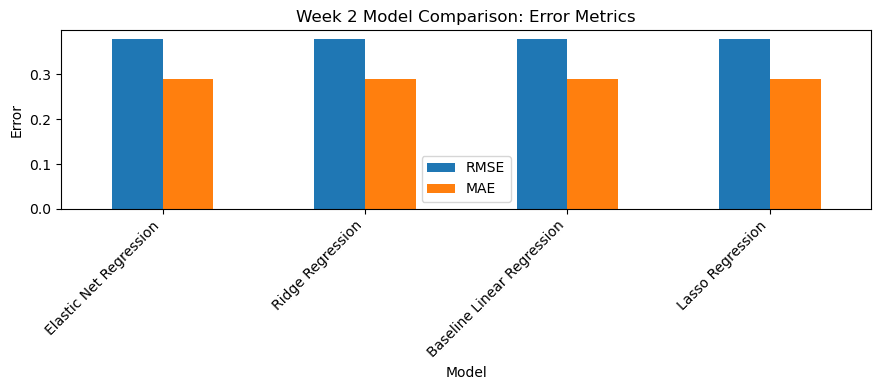

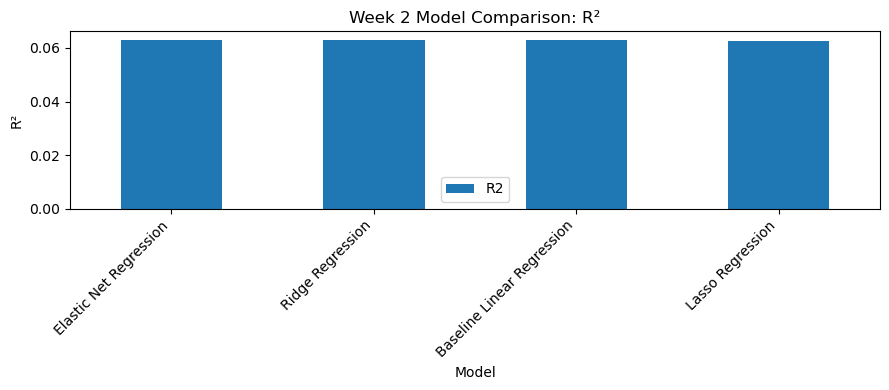

In [20]:
# Plot model comparison

results_df.set_index("Model")[["RMSE", "MAE"]].plot(kind="bar", figsize=(9, 4))
plt.title("Week 2 Model Comparison: Error Metrics")
plt.ylabel("Error")
plt.xlabel("Model")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

results_df.set_index("Model")[["R2"]].plot(kind="bar", figsize=(9, 4))
plt.title("Week 2 Model Comparison: R²")
plt.ylabel("R²")
plt.xlabel("Model")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## 6. Compare coefficients

This section looks at which predictors are receiving the strongest coefficients. This is useful because regularization can make the model easier to interpret, especially when predictors are related to each other.

The coefficients are based on scaled features, so they can be compared more fairly.

In [21]:
coef_table = pd.DataFrame({"Feature": features})

for name, model in models.items():
    reg_model = model.named_steps["model"]
    coef_table[name] = reg_model.coef_

coef_table["Lasso_abs"] = coef_table["Lasso Regression"].abs()

coef_table_sorted = coef_table.sort_values("Lasso_abs", ascending=False)
coef_table_sorted.head(15)


,Feature,Baseline Linear Regression,Ridge Regression,Lasso Regression,Elastic Net Regression,Lasso_abs
24,DEP_BLOCK_HIST,0.061265,0.061263,0.061524,0.061272,0.061524
16,PRCP,0.028724,0.028724,0.028007,0.028347,0.028007
21,CARRIER_HISTORICAL,0.021222,0.021222,0.021932,0.021725,0.021932
20,AWND,0.014765,0.014765,0.014256,0.014588,0.014256
17,SNOW,0.014477,0.014477,0.014025,0.014258,0.014025
22,DEP_AIRPORT_HIST,0.013419,0.013419,0.012754,0.013123,0.012754
2,DISTANCE_GROUP,0.010405,0.010405,0.008580,0.009305,0.008580
5,NUMBER_OF_SEATS,0.016289,0.016286,0.008309,0.010675,0.008309
0,MONTH,0.008347,0.008348,0.008053,0.008661,0.008053
3,SEGMENT_NUMBER,0.008891,0.008892,0.007793,0.008509,0.007793


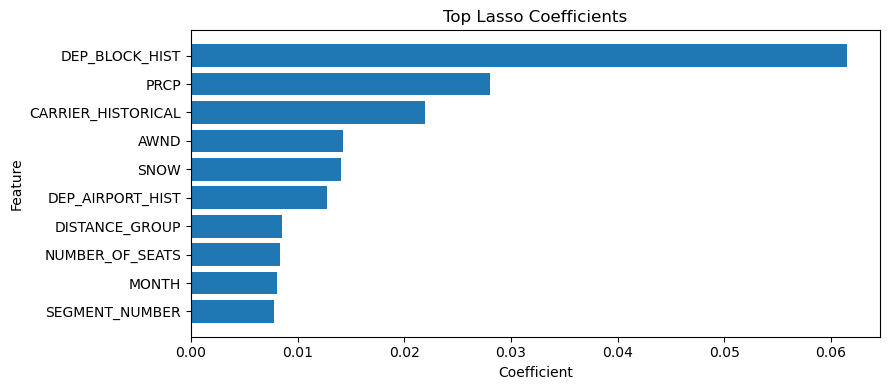

In [22]:
# Top Lasso coefficients

top_lasso = coef_table_sorted.head(10).copy()

plt.figure(figsize=(9, 4))
plt.barh(top_lasso["Feature"], top_lasso["Lasso Regression"])
plt.title("Top Lasso Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


## 7. Try a small alpha grid

This is a simple form of hyperparameter tuning. The value of `alpha` controls how strong the regularization is:

- smaller alpha = less shrinkage
- larger alpha = more shrinkage

The goal is to see whether stronger or weaker regularization improves validation performance.

In [23]:
alphas = [0.0001, 0.001, 0.01, 0.1, 1.0, 10.0]

tuning_results = []

for alpha in alphas:
    ridge_model = Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=alpha, random_state=RANDOM_STATE))
    ])
    ridge_model.fit(X_train, y_train)
    ridge_preds = ridge_model.predict(X_valid)

    tuning_results.append({
        "Model": "Ridge",
        "Alpha": alpha,
        "RMSE": mean_squared_error(y_valid, ridge_preds, squared=False),
        "MAE": mean_absolute_error(y_valid, ridge_preds),
        "R2": r2_score(y_valid, ridge_preds)
    })

    lasso_model = Pipeline([
        ("scaler", StandardScaler()),
        ("model", Lasso(alpha=alpha, random_state=RANDOM_STATE, max_iter=10000))
    ])
    lasso_model.fit(X_train, y_train)
    lasso_preds = lasso_model.predict(X_valid)

    tuning_results.append({
        "Model": "Lasso",
        "Alpha": alpha,
        "RMSE": mean_squared_error(y_valid, lasso_preds, squared=False),
        "MAE": mean_absolute_error(y_valid, lasso_preds),
        "R2": r2_score(y_valid, lasso_preds)
    })

tuning_df = pd.DataFrame(tuning_results)
tuning_df.sort_values("RMSE").head(10)


,Model,Alpha,RMSE,MAE,R2
1,Lasso,0.0001,0.379547,0.289636,6.305875e-02
10,Ridge,10.0000,0.379557,0.289590,6.300669e-02
8,Ridge,1.0000,0.379558,0.289589,6.300463e-02
6,Ridge,0.1000,0.379558,0.289589,6.300442e-02
4,Ridge,0.0100,0.379558,0.289589,6.300440e-02
2,Ridge,0.0010,0.379558,0.289589,6.300440e-02
0,Ridge,0.0001,0.379558,0.289589,6.300440e-02
3,Lasso,0.0010,0.379612,0.290095,6.273769e-02
5,Lasso,0.0100,0.380944,0.293807,5.614723e-02
7,Lasso,0.1000,0.392111,0.307494,-1.156269e-09


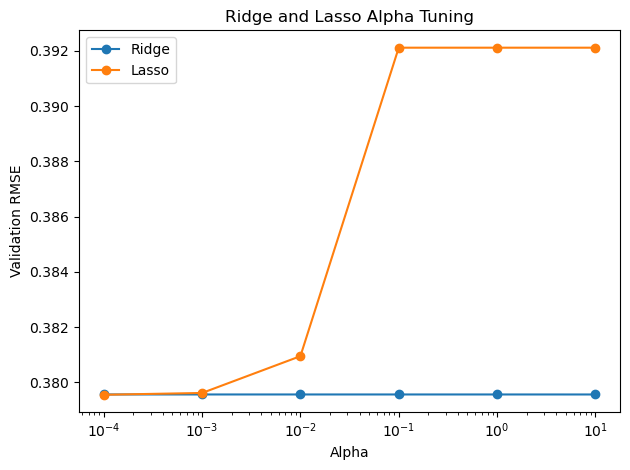

In [24]:
# Plot tuning results

for model_name in tuning_df["Model"].unique():
    subset = tuning_df[tuning_df["Model"] == model_name]
    plt.plot(subset["Alpha"], subset["RMSE"], marker="o", label=model_name)

plt.xscale("log")
plt.title("Ridge and Lasso Alpha Tuning")
plt.xlabel("Alpha")
plt.ylabel("Validation RMSE")
plt.legend()
plt.tight_layout()
plt.show()


## Week 2 Conclusion

In this notebook, I used Ridge, Lasso, and Elastic Net regression on the flight delay dataset. These models were useful because regularization can reduce overfitting and make coefficients more stable when predictors are related to each other.

The regularized models performed very similarly to the basic linear regression results. Elastic Net had the lowest RMSE, but the difference was very small. The R² values also stayed low, meaning the models still explained only a small amount of the variation in `DEP_DEL15`.

Overall, regularization helped more with model stability and interpretation than with major predictive improvement. This showed that the dataset has useful predictors, but regularized linear regression still may not be flexible enough to fully model flight delay risk.
